# Bring in Data

In [8]:
import pandas as pd
import numpy as np
import os 

data_folder = os.path.join(os.getcwd(), "data")
df = pd.read_csv(os.path.join(data_folder, "sales_pipeline.csv"))

df.head(10)

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0
5,ZNBS69V1,Anna Snelling,MG Special,Ron-tech,Won,2016-10-29,2017-03-01,49.0
6,9ME3374G,Vicki Laflamme,MG Special,J-Texon,Won,2016-10-30,2017-03-02,57.0
7,7GN8Q4LL,Markita Hansen,GTX Basic,Cheers,Won,2016-11-01,2017-03-07,601.0
8,OLK9LKZB,Niesha Huffines,GTX Plus Basic,Zumgoity,Won,2016-11-01,2017-03-03,1026.0
9,HAXMC4IX,James Ascencio,MG Advanced,NaN,Engaging,2016-11-03,NaN,NaN


# Merging Datasets

In [14]:
df_products = pd.read_csv(os.path.join(data_folder, "products.csv"))
df_teams = pd.read_csv(os.path.join(data_folder, "sales_teams.csv"))
df_accounts = pd.read_csv(os.path.join(data_folder, "accounts.csv"))

df_merged = (
    df
    .merge(df_accounts, on="account", how="left")      # add account info
    .merge(df_products, on="product", how="left")      # add product info
    .merge(df_teams, on="sales_agent", how="left")     # add sales team info
)

df_merged.head(10)

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,sector,year_established,revenue,employees,office_location,subsidiary_of,series,sales_price,manager,regional_office
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,retail,2001.0,718.62,2448.0,United States,NaN,GTX,1096.0,Dustin Brinkmann,Central
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,medical,2002.0,3178.24,4540.0,United States,NaN,NaN,NaN,Melvin Marxen,Central
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,retail,2001.0,718.62,2448.0,United States,NaN,MG,55.0,Melvin Marxen,Central
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,software,1998.0,2714.90,2641.0,United States,Acme Corporation,GTX,550.0,Dustin Brinkmann,Central
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,services,1982.0,792.46,1299.0,United States,NaN,GTX,550.0,Summer Sewald,West
5,ZNBS69V1,Anna Snelling,MG Special,Ron-tech,Won,2016-10-29,2017-03-01,49.0,medical,1992.0,3922.42,6837.0,United States,NaN,MG,55.0,Dustin Brinkmann,Central
6,9ME3374G,Vicki Laflamme,MG Special,J-Texon,Won,2016-10-30,2017-03-02,57.0,retail,1989.0,1388.67,3583.0,United States,NaN,MG,55.0,Celia Rouche,West
7,7GN8Q4LL,Markita Hansen,GTX Basic,Cheers,Won,2016-11-01,2017-03-07,601.0,entertainment,1993.0,4269.90,6472.0,United States,Massive Dynamic,GTX,550.0,Celia Rouche,West
8,OLK9LKZB,Niesha Huffines,GTX Plus Basic,Zumgoity,Won,2016-11-01,2017-03-03,1026.0,medical,1984.0,441.08,1210.0,United States,NaN,GTX,1096.0,Melvin Marxen,Central
9,HAXMC4IX,James Ascencio,MG Advanced,NaN,Engaging,2016-11-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MG,3393.0,Summer Sewald,West


# Handling Missing Values and Outliers

### Missing Values

In [16]:
df.isnull().sum()

opportunity_id       0
sales_agent          0
product              0
account           1425
deal_stage           0
engage_date        500
close_date        2089
close_value       2089
dtype: int64

In these cases, close_date and close_value should not be replaced with fake values, since having a null value simply means the deal hasn't been closed yet. That's why they exist. In this case, we should just be careful with how we train our models, but I wont do anything else about it at this stage.

In [49]:
df_merged[df_merged['account'].isnull()].head()

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,sector,year_established,revenue,employees,office_location,subsidiary_of,series,sales_price,manager,regional_office
9,HAXMC4IX,James Ascencio,MG Advanced,NaN,Engaging,2016-11-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MG,3393.0,Summer Sewald,West
42,EG7OFLFR,Kami Bicknell,GTX Basic,NaN,Engaging,2016-11-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GTX,550.0,Summer Sewald,West
44,OLVI7L8M,Cassey Cress,GTXPro,NaN,Engaging,2016-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rocco Neubert,East
56,F5U1ACDD,Kami Bicknell,GTX Plus Basic,NaN,Engaging,2016-11-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GTX,1096.0,Summer Sewald,West
60,ZZY4516R,Hayden Neloms,MG Advanced,NaN,Engaging,2016-11-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MG,3393.0,Celia Rouche,West


In [46]:
print("Number of examples Won with no account:", df_merged[(df_merged['deal_stage'] == "Won") & (df_merged['account'].isnull())].shape[0])
print("Number of examples Lost with no account:", df_merged[(df_merged['deal_stage'] == "Lost") & (df_merged['account'].isnull())].shape[0])
print("Number of examples Engaging with no account:", df_merged[(df_merged['deal_stage'] == "Engaging") & (df_merged['account'].isnull())].shape[0])
print("Number of examples Prospecting with no account:", df_merged[(df_merged['deal_stage'] == "Prospecting") & (df_merged['account'].isnull())].shape[0])

Number of examples Won with no account: 0
Number of examples Lost with no account: 0
Number of examples Engaging with no account: 1088
Number of examples Prospecting with no account: 337


All missing accounts are in Prospecting or Engaging stages, and none exist for Won/Lost deals, suggesting that account assignment is part of opportunity qualification — its absence is a strong signal of deal immaturity rather than random missing data

In [34]:
df_merged[df_merged['engage_date'].isnull()].head()

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,sector,year_established,revenue,employees,office_location,subsidiary_of,series,sales_price,manager,regional_office
8300,6CWZFOHJ,Anna Snelling,GTX Basic,Green-Plus,Prospecting,NaN,NaN,NaN,services,2003.0,692.19,1922.0,United States,NaN,GTX,550.0,Dustin Brinkmann,Central
8301,3LCLVRVV,Anna Snelling,GTX Basic,NaN,Prospecting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GTX,550.0,Dustin Brinkmann,Central
8302,YIU1B39V,Anna Snelling,GTX Basic,NaN,Prospecting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GTX,550.0,Dustin Brinkmann,Central
8303,8E0VRCLW,Anna Snelling,GTX Basic,NaN,Prospecting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GTX,550.0,Dustin Brinkmann,Central
8304,G99CS23F,Anna Snelling,GTX Basic,NaN,Prospecting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GTX,550.0,Dustin Brinkmann,Central


In [51]:
print("Number of examples Prospecting with no engage data:", df_merged[(df_merged['deal_stage'] == "Prospecting") & (df_merged['engage_date'].isnull())].shape[0])

Number of examples Prospecting with no engage data: 500


We can also see here that all instances with no engage_date simply means it's in the Prospecting stage. Once again, the missingness is not random, but alludes the fact that the deal is in a very early stage.

In this dataset, missing values are not random — they’re tied to pipeline stage and business process. For example, account is missing only in Prospecting or Engaging, close_date and close_value are missing only for open deals, and engage_date is missing for unworked leads. Because the missingness itself carries business meaning, we won’t impute or drop these values in the preparation stage. Instead, cantransform them into informative features (e.g., has_account, is_closed, days_open) during feature engineering. This way, the model learns from both the raw data and the structure of the sales process.

## Outliers

In [73]:
numeric_df = df_merged.select_dtypes(include=['float64', 'int64'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))

print(outliers.sum())  # number of outliers per numeric column

close_value          15
year_established      0
revenue             661
employees           434
sales_price          40
dtype: int64


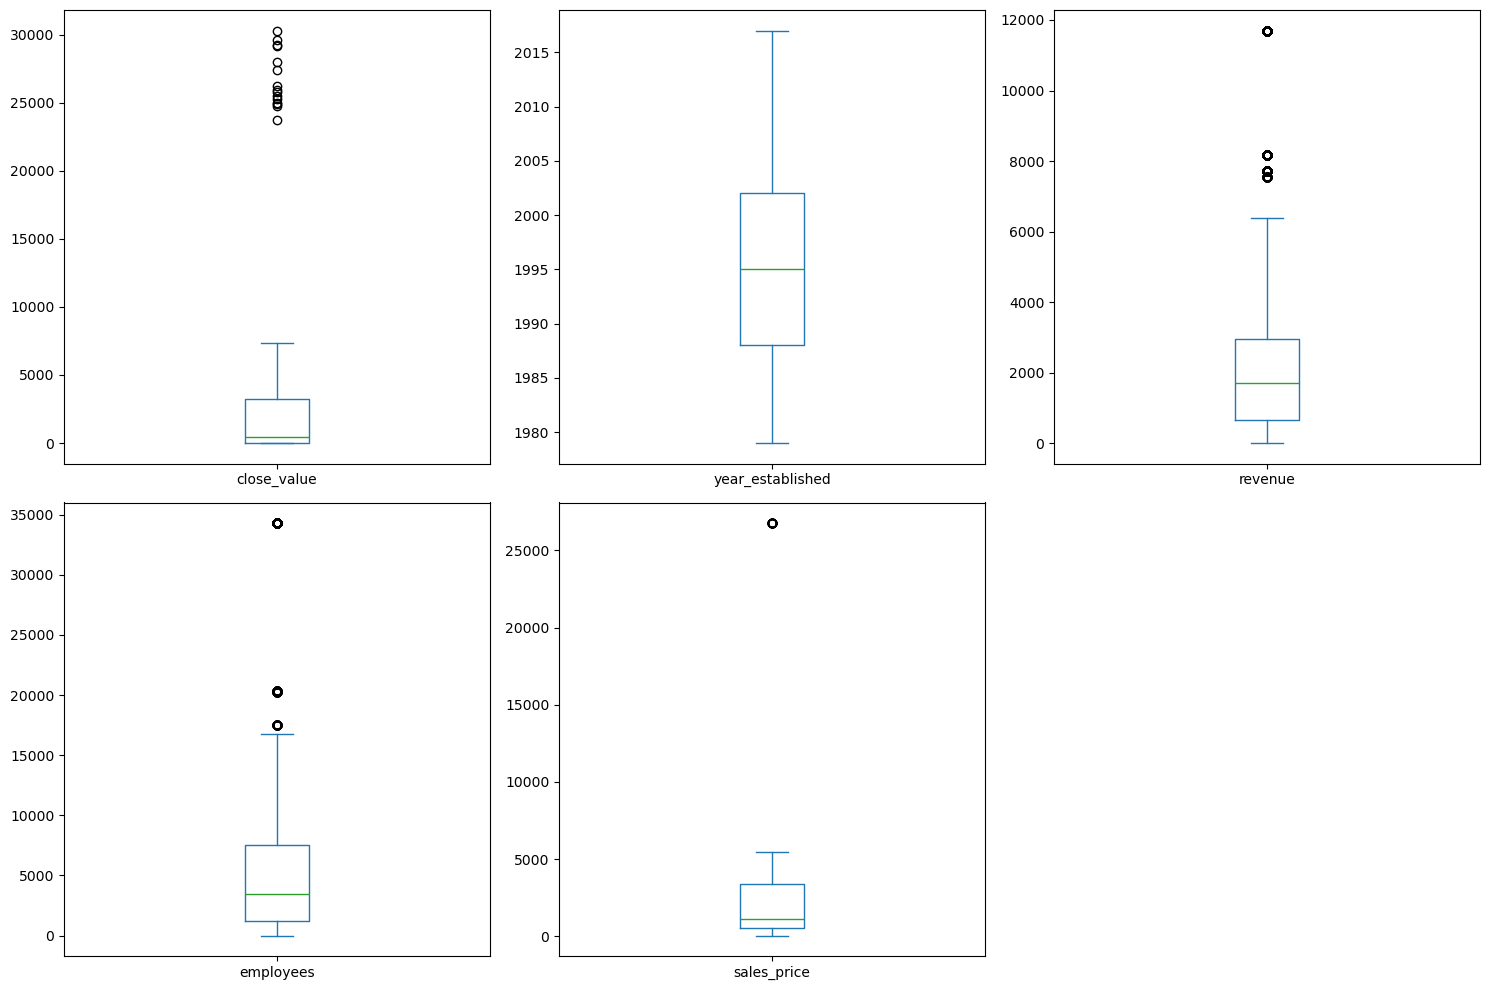

In [75]:
import matplotlib.pyplot as plt

numeric_df.plot(kind='box', subplots=True, layout=(len(numeric_df.columns)//3 + 1, 3),
                figsize=(15, 10), sharex=False, sharey=False)

plt.tight_layout()
plt.show()

From analyzing the data, I decided to log-transform close_value, revenue, and employees because they vary across many orders of magnitude and are highly skewed, which can distort models. By contrast, sales_price is fixed by the product catalog, and year_established is naturally bounded and more interpretable as-is, so they don’t need log transformation.

Also, I decided to use log transformation because the variables are naturally right-skewed (revenues, employees, deal sizes grow multiplicatively), and log rescales the whole distribution to be more normal-like while preserving relative differences. Winsorization only caps extremes and can discard useful signal, making it less suited here.

In [79]:
cols_to_log = ["close_value", "revenue", "employees"]

for col in cols_to_log:
    df_merged[col + "_log"] = np.log1p(df_merged[col])

df_merged[["close_value", "close_value_log",
           "revenue", "revenue_log",
           "employees", "employees_log"]].head()

,close_value,close_value_log,revenue,revenue_log,employees,employees_log
0,1054.0,6.961296,718.62,6.578723,2448.0,7.803435
1,4514.0,8.415160,3178.24,8.064397,4540.0,8.420903
2,50.0,3.931826,718.62,6.578723,2448.0,7.803435
3,588.0,6.378426,2714.90,7.906879,2641.0,7.879291
4,517.0,6.249975,792.46,6.676403,1299.0,7.170120


## Filter Unecessary Columns

In [85]:
print(df_merged.columns)

Index(['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage',
       'engage_date', 'close_date', 'close_value', 'sector',
       'year_established', 'revenue', 'employees', 'office_location',
       'subsidiary_of', 'series', 'sales_price', 'manager', 'regional_office',
       'close_value_log', 'revenue_log', 'employees_log'],
      dtype='object')


Here, we can see opportunity_id is the only column safe to remove because it is merely a unique identifier and carries no predictive or explanatory value for the model.

In [87]:
df_merged.drop(columns=["opportunity_id"], inplace=True)
print(df_merged.columns)

Index(['sales_agent', 'product', 'account', 'deal_stage', 'engage_date',
       'close_date', 'close_value', 'sector', 'year_established', 'revenue',
       'employees', 'office_location', 'subsidiary_of', 'series',
       'sales_price', 'manager', 'regional_office', 'close_value_log',
       'revenue_log', 'employees_log'],
      dtype='object')


Lead scoring: Target = probability of moving from Prospecting/Engaging → Won.   
Win prediction: Target = Won vs. Lost.   
Health scoring: Continuous score combining days_open, has_account, deal_stage, and account/product strength.  

# Whats Next: Feature Engineering + Exploratory Data Analysis (Generate Summary Statistics)
- Find features to one-hot encode
- Create has_account feature
- Discuss: Creation of days_open and deal_length features? Would need to ask if it would be smart to use the latest occuring date in dataset for "today"

### Remember as you're data prepping:
Lead scoring: Target = probability of moving from Prospecting/Engaging → Won.  
Win prediction: Target = Won vs. Lost.  
Health scoring: Continuous score combining days_open, has_account, deal_stage, and account/product strength.  